### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/CIFAR10%20UNet%20Diffusion%20CLF.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Ffiles%2Fnotebooks%2FCIFAR10%2520UNet%2520Diffusion%2520CLF.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Ffiles%2Fnotebooks%2FCIFAR10%20UNet%20Diffusion%20CLF.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/CIFAR10%20UNet%20Diffusion%20CLF.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [1]:
"""Prepare a notebook checkout and runtime before importing scientific packages.

This canonical first-cell source is copied into maintained notebooks and generated
HPO notebooks. Edit REVISION/RUNTIME/CUDA before execution when needed. Existing
checkouts are reused without fetching; only missing setup code is downloaded.
ROOT is the selected absolute pathlib.Path; RUNTIME_PACKAGES maps package names
to installed version strings. Preparation may clone/install under the selected
policy and changes cwd/import paths through files.notebooks.init.prepare_notebook.
"""
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME, 
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "files" / "notebooks" / "init.py" for path in _locations
                     if (path / "files" / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/files/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, 
    repository=REPOSITORY, 
    revision=REVISION, 
    runtime=RUNTIME, 
    cuda=CUDA
)

Repository ready: /workspace (runtime: local)
Runtime packages ready: Python 3.11.13, TensorFlow 2.20.0, Keras 3.11.2


In [2]:
from common import utils
from common.dataloader import get_dataset


utils.init()

2026-10-08 12:57:26.100417: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Experiment settings

Train a joint CIFAR10 denoiser and ten-class classifier with the UNet architecture. Keep the same 50-epoch schedule and five-epoch validation interval as the UNet diffusion notebook.


In [3]:
from tensorflow import keras


epochs = 50
val_freq = 5
seed = 42

keras.utils.set_random_seed(seed)

## CIFAR10 data

Keep raw pixel values and labels 0-9; the wrapper handles standardization and CFG label mapping. As in the CIFAR10 DiT CLF notebook, train on the full training split and use the official test split for monitoring.


In [4]:
from common.dataloader import load_cifar10


x_train, y_train, _, _, x_test, y_test = load_cifar10(
    indices=None, 
    validation_ratio=0.0, 
    verbose=0
)

trainset = get_dataset(
    x_train, 
    y_train.reshape(-1), 
    seed=seed
)
valset = get_dataset(
    x_test, 
    y_test.reshape(-1), 
    shuffle_buffer=0, 
    drop_remainder=False
)

2026-10-08 12:58:03.884014: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1791464283.884609    1998 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


## UNet denoiser and classifier

Use three encoder/decoder widths and a 128-channel bottleneck. The classifier pools the final UNet stage into ten class probabilities. The wrapper trains denoising and classification jointly; classifier supervision uses null-conditioned rows.


In [5]:
from diffusion.models.convolution.unet_classifier import UNetClassifier
from diffusion.models.wrapper.diffusion_classifier import DiffusionClassifier


unet = UNetClassifier(
    num_classes=10, 
    use_cfg=True, 
    image_size=32, 
    channels=3, 
    widths=(32, 64, 96), 
    block_depth=2, 
    bottleneck_width=128, 
    bottleneck_depth=2, 
    clf_dim=96, 
    clf_depth=1, 
    clf_block_depth=1, 
    force_global_avg_pooling=True, 
    seed=seed
)
model = DiffusionClassifier(
    network=unet, 
    preprocess_type="standardize", 
    mask_by_nulls=True, 
    seed=seed
)

unet.summary()

Model: "u_net_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_embedder (Conv2D)         │ (None, 32, 32, 21)     │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_embedder                   │ (None, 22)             │        22,000 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ label_embedder                  │ (None, 21)             │           231 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_1 (LayerDict)             │ (None, 32, 32, 32)     │        51,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_2 (LayerDict)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_3 (LayerDict)             │ (None, 16, 16, 64)     │       137,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_4 (LayerDict)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_5 (LayerDict)             │ (None, 8, 8, 96)       │       319,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_6 (LayerDict)             │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_7 (LayerDict)             │ (None, 4, 4, 128)      │       577,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_8 (LayerDict)             │ (None, 8, 8, 96)       │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_9 (LayerDict)             │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_10 (LayerDict)            │ (None, 8, 8, 96)       │       442,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_11 (LayerDict)            │ (None, 16, 16, 64)     │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_12 (LayerDict)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_13 (LayerDict)            │ (None, 16, 16, 64)     │       198,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_14 (LayerDict)            │ (None, 32, 32, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_15 (LayerDict)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_16 (LayerDict)            │ (None, 32, 32, 32)     │        51,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ noise_projection (Conv2D)       │ (None, 32, 32, 3)      │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_noise (Activation)    │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_feature_extractor    │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clf_depth_1 (LayerDict)         │ (None, 32, 32, 96)     │       170,496 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,002,296 (7.64 MB)

 Trainable params: 1,977,800 (7.54 MB)

 Non-trainable params: 24,496 (95.69 KB)

## Optimizer

Use Adam with cosine decay. The compiled MSE loss trains noise prediction; DiffusionClassifier adds its classification cross-entropy internally.


In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse"
)


## Training

Train on the full training split. Validation and sample previews run every `val_freq` epochs.


In [7]:
from tensorflow.keras import callbacks

from diffusion.callbacks.image_generator import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator(frequency=val_freq, seed=seed)
]

Epoch 1/50


2026-10-08 12:58:32.885997: I external/local_xla/xla/service/service.cc:163] XLA service 0x74387001e2f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-10-08 12:58:32.886032: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-10-08 12:58:33.451063: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-10-08 12:58:36.658838: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92600
2026-10-08 12:58:39.441965: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[128,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,64,32,32]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call

390/390 ━━━━━━━━━━━━━━━━━━━━ 91s 115ms/step - classifier_accuracy: 0.1412 - classifier_loss: 2.5648 - loss: 0.1202 - noise_loss: 0.0981 - learning_rate: 9.9901e-04
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - classifier_accuracy: 0.1991 - classifier_loss: 2.1540 - loss: 0.0585 - noise_loss: 0.0400 - learning_rate: 9.9606e-04
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - classifier_accuracy: 0.2080 - classifier_loss: 2.0693 - loss: 0.0550 - noise_loss: 0.0372 - learning_rate: 9.9114e-04
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - classifier_accuracy: 0.2406 - classifier_loss: 2.0170 - loss: 0.0536 - noise_loss: 0.0363 - learning_rate: 9.8429e-04
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - classifier_accuracy: 0.2464 - classifier_loss: 1.9739 - loss: 0.0522 - noise_loss: 0.0352

2026-10-08 13:03:04.801014: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,32,32]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-10-08 13:03:04.865289: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,32,32]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

390/390 ━━━━━━━━━━━━━━━━━━━━ 67s 173ms/step - classifier_accuracy: 0.2567 - classifier_loss: 1.9746 - loss: 0.0522 - noise_loss: 0.0352 - val_classifier_accuracy: 0.2607 - val_classifier_loss: 1.9476 - val_image_loss: 3.6067 - val_loss: 0.1953 - val_noise_loss: 0.1785 - learning_rate: 9.7553e-04
Steps: 50/50


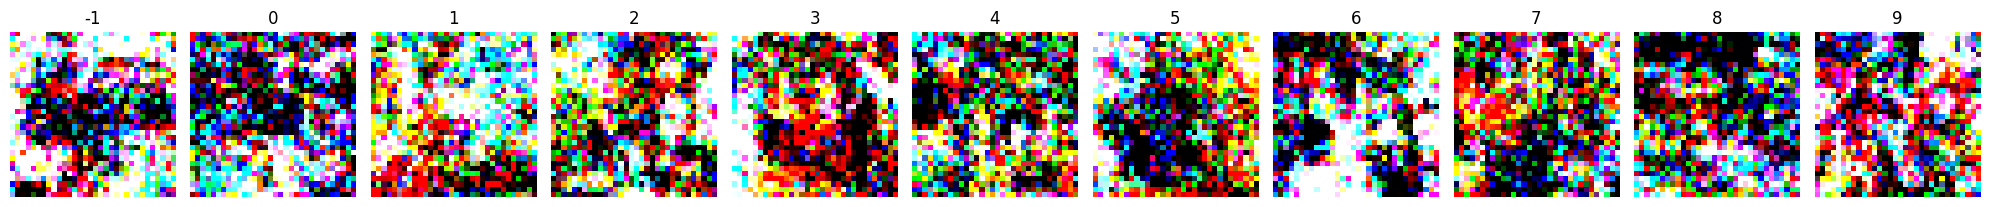

Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - classifier_accuracy: 0.2694 - classifier_loss: 1.9460 - loss: 0.0517 - noise_loss: 0.0350 - learning_rate: 9.6489e-04
Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - classifier_accuracy: 0.2845 - classifier_loss: 1.9373 - loss: 0.0512 - noise_loss: 0.0346 - learning_rate: 9.5241e-04
Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - classifier_accuracy: 0.3023 - classifier_loss: 1.9030 - loss: 0.0505 - noise_loss: 0.0342 - learning_rate: 9.3815e-04
Epoch 9/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - classifier_accuracy: 0.2863 - classifier_loss: 1.9094 - loss: 0.0503 - noise_loss: 0.0340 - learning_rate: 9.2216e-04
Epoch 10/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 54s 138ms/step - classifier_accuracy: 0.3105 - classifier_loss: 1.8685 - loss: 0.0495 - noise_loss: 0.0335 - val_classifier_accuracy: 0.4551 - val_classifier_loss: 1.5216 - val_image_loss: 0.1209 - val_loss: 0.0527 - val_noise_loss: 0.0396 - learning_rate: 9.

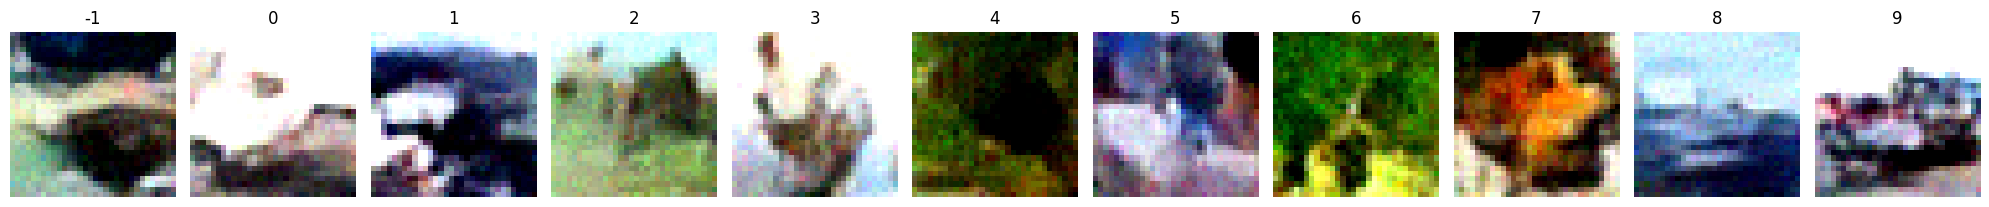

Epoch 11/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - classifier_accuracy: 0.3242 - classifier_loss: 1.8408 - loss: 0.0494 - noise_loss: 0.0335 - learning_rate: 8.8526e-04
Epoch 12/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.3180 - classifier_loss: 1.8299 - loss: 0.0489 - noise_loss: 0.0331 - learning_rate: 8.6448e-04
Epoch 13/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 52s 134ms/step - classifier_accuracy: 0.3312 - classifier_loss: 1.8155 - loss: 0.0485 - noise_loss: 0.0329 - learning_rate: 8.4227e-04
Epoch 14/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 52s 134ms/step - classifier_accuracy: 0.3399 - classifier_loss: 1.7893 - loss: 0.0485 - noise_loss: 0.0331 - learning_rate: 8.1871e-04
Epoch 15/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 61s 156ms/step - classifier_accuracy: 0.3400 - classifier_loss: 1.7808 - loss: 0.0480 - noise_loss: 0.0326 - val_classifier_accuracy: 0.5167 - val_classifier_loss: 1.3467 - val_image_loss: 0.1264 - val_loss: 0.0440 - val_noise_loss: 0.0324 - learning_rate

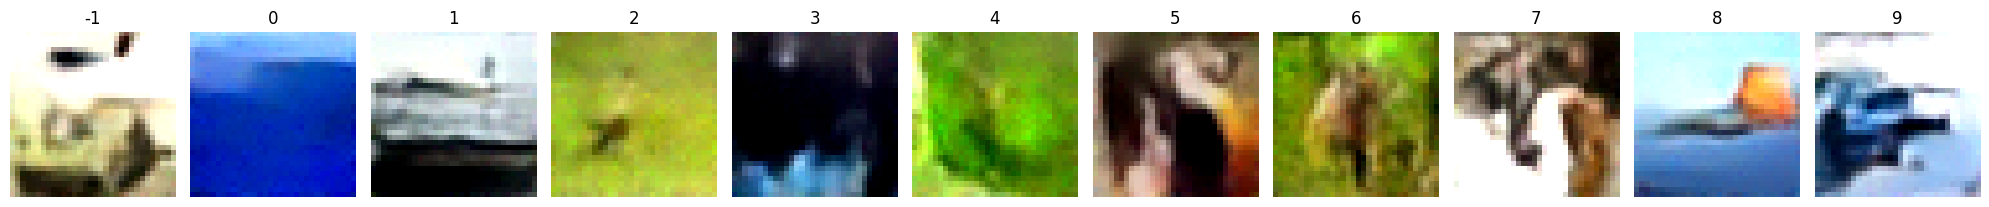

Epoch 16/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 129ms/step - classifier_accuracy: 0.3545 - classifier_loss: 1.7640 - loss: 0.0477 - noise_loss: 0.0325 - learning_rate: 7.6791e-04
Epoch 17/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.3522 - classifier_loss: 1.7580 - loss: 0.0474 - noise_loss: 0.0323 - learning_rate: 7.4088e-04
Epoch 18/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.3620 - classifier_loss: 1.7335 - loss: 0.0471 - noise_loss: 0.0322 - learning_rate: 7.1289e-04
Epoch 19/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.3629 - classifier_loss: 1.7296 - loss: 0.0468 - noise_loss: 0.0319 - learning_rate: 6.8406e-04
Epoch 20/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - classifier_accuracy: 0.3719 - classifier_loss: 1.7026 - loss: 0.0465 - noise_loss: 0.0318 - val_classifier_accuracy: 0.5696 - val_classifier_loss: 1.2084 - val_image_loss: 0.1016 - val_loss: 0.0416 - val_noise_loss: 0.0313 - learning_rate

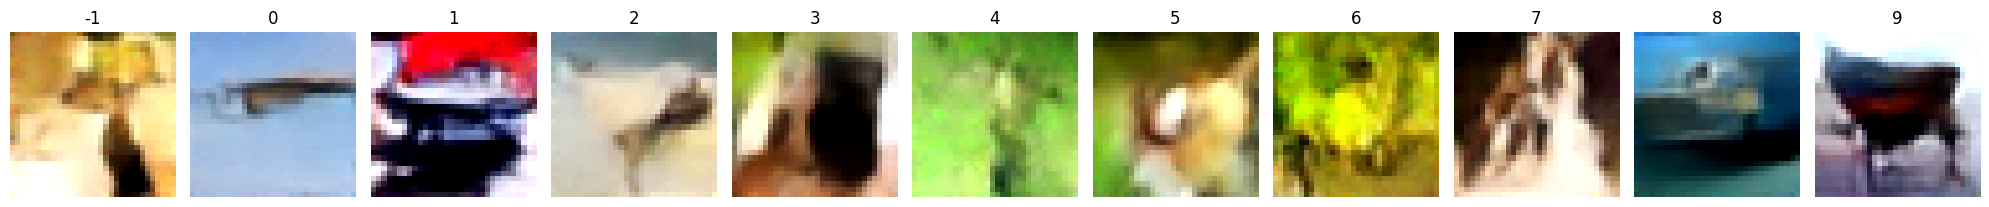

Epoch 21/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.3795 - classifier_loss: 1.6866 - loss: 0.0462 - noise_loss: 0.0318 - learning_rate: 6.2435e-04
Epoch 22/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.3981 - classifier_loss: 1.6524 - loss: 0.0457 - noise_loss: 0.0315 - learning_rate: 5.9369e-04
Epoch 23/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.3831 - classifier_loss: 1.6581 - loss: 0.0456 - noise_loss: 0.0313 - learning_rate: 5.6267e-04
Epoch 24/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.4075 - classifier_loss: 1.6329 - loss: 0.0453 - noise_loss: 0.0313 - learning_rate: 5.3140e-04
Epoch 25/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - classifier_accuracy: 0.3975 - classifier_loss: 1.6447 - loss: 0.0453 - noise_loss: 0.0312 - val_classifier_accuracy: 0.5942 - val_classifier_loss: 1.1251 - val_image_loss: 0.1054 - val_loss: 0.0412 - val_noise_loss: 0.0315 - learning_rate

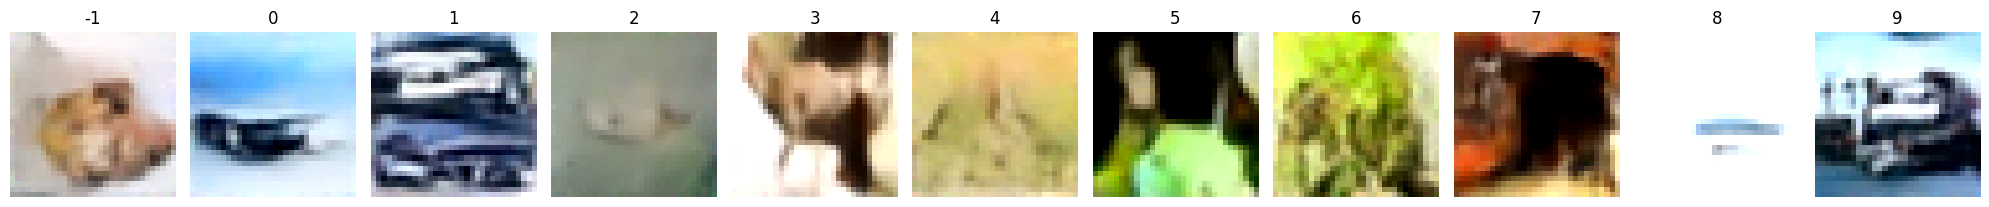

Epoch 26/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - classifier_accuracy: 0.4191 - classifier_loss: 1.6016 - loss: 0.0450 - noise_loss: 0.0312 - learning_rate: 4.6860e-04
Epoch 27/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 55s 141ms/step - classifier_accuracy: 0.4218 - classifier_loss: 1.5911 - loss: 0.0450 - noise_loss: 0.0313 - learning_rate: 4.3733e-04
Epoch 28/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - classifier_accuracy: 0.4181 - classifier_loss: 1.5743 - loss: 0.0443 - noise_loss: 0.0308 - learning_rate: 4.0631e-04
Epoch 29/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.4394 - classifier_loss: 1.5481 - loss: 0.0441 - noise_loss: 0.0309 - learning_rate: 3.7566e-04
Epoch 30/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - classifier_accuracy: 0.4374 - classifier_loss: 1.5446 - loss: 0.0439 - noise_loss: 0.0306 - val_classifier_accuracy: 0.6200 - val_classifier_loss: 1.0331 - val_image_loss: 0.0960 - val_loss: 0.0397 - val_noise_loss: 0.0308 - learning_rate

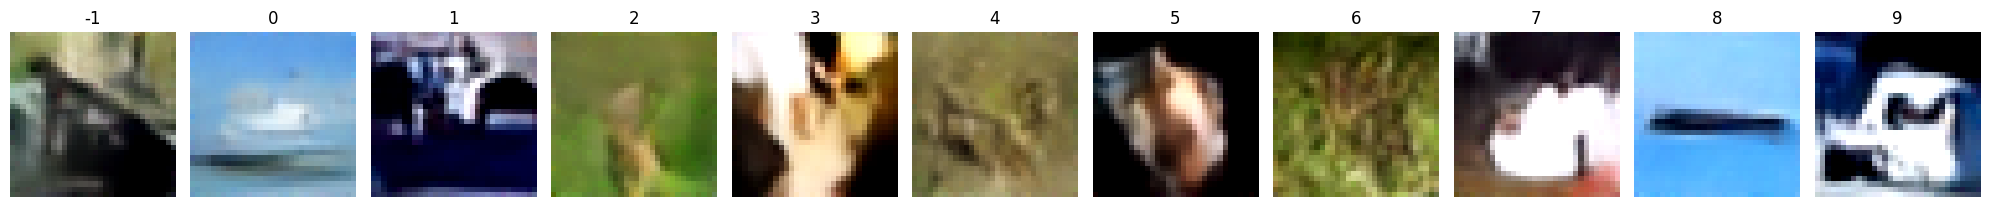

Epoch 31/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - classifier_accuracy: 0.4468 - classifier_loss: 1.5139 - loss: 0.0437 - noise_loss: 0.0307 - learning_rate: 3.1594e-04
Epoch 32/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.4601 - classifier_loss: 1.5017 - loss: 0.0436 - noise_loss: 0.0307 - learning_rate: 2.8711e-04
Epoch 33/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.4476 - classifier_loss: 1.5274 - loss: 0.0435 - noise_loss: 0.0303 - learning_rate: 2.5912e-04
Epoch 34/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.4515 - classifier_loss: 1.5065 - loss: 0.0436 - noise_loss: 0.0306 - learning_rate: 2.3209e-04
Epoch 35/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - classifier_accuracy: 0.4582 - classifier_loss: 1.4816 - loss: 0.0432 - noise_loss: 0.0304 - val_classifier_accuracy: 0.6322 - val_classifier_loss: 0.9972 - val_image_loss: 0.0932 - val_loss: 0.0392 - val_noise_loss: 0.0306 - learning_rate

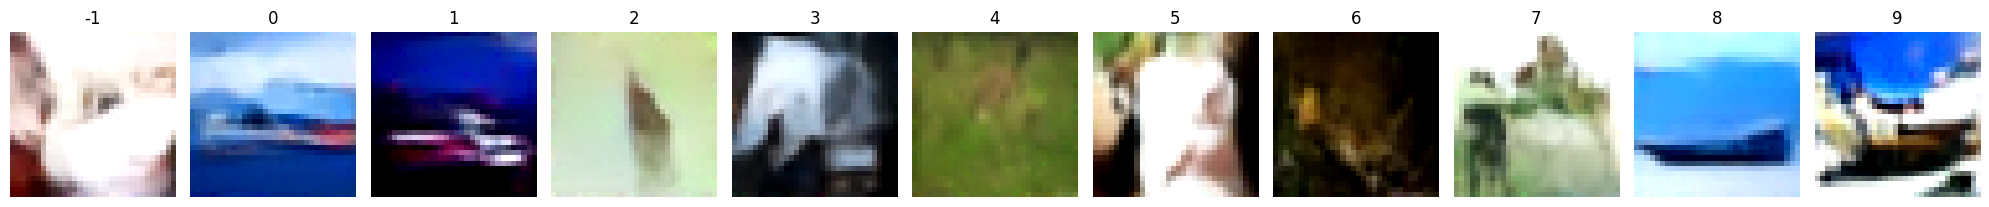

Epoch 36/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.4580 - classifier_loss: 1.4825 - loss: 0.0432 - noise_loss: 0.0304 - learning_rate: 1.8129e-04
Epoch 37/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.4747 - classifier_loss: 1.4595 - loss: 0.0429 - noise_loss: 0.0303 - learning_rate: 1.5773e-04
Epoch 38/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.4691 - classifier_loss: 1.4438 - loss: 0.0425 - noise_loss: 0.0301 - learning_rate: 1.3552e-04
Epoch 39/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.4803 - classifier_loss: 1.4397 - loss: 0.0425 - noise_loss: 0.0301 - learning_rate: 1.1474e-04
Epoch 40/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - classifier_accuracy: 0.4895 - classifier_loss: 1.4038 - loss: 0.0422 - noise_loss: 0.0301 - val_classifier_accuracy: 0.6483 - val_classifier_loss: 0.9642 - val_image_loss: 0.0950 - val_loss: 0.0387 - val_noise_loss: 0.0304 - learning_rate

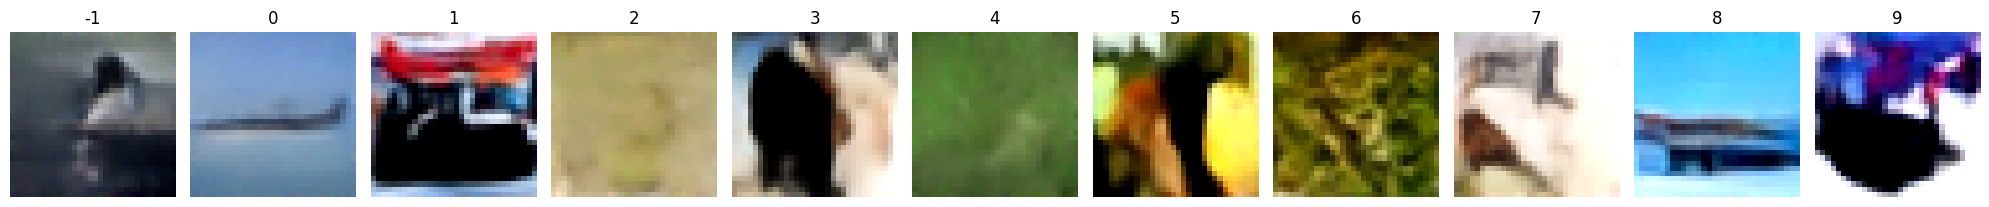

Epoch 41/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 129ms/step - classifier_accuracy: 0.5032 - classifier_loss: 1.3996 - loss: 0.0420 - noise_loss: 0.0300 - learning_rate: 7.7836e-05
Epoch 42/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.4991 - classifier_loss: 1.4033 - loss: 0.0419 - noise_loss: 0.0298 - learning_rate: 6.1847e-05
Epoch 43/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.4995 - classifier_loss: 1.3770 - loss: 0.0417 - noise_loss: 0.0299 - learning_rate: 4.7586e-05
Epoch 44/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - classifier_accuracy: 0.4802 - classifier_loss: 1.3940 - loss: 0.0418 - noise_loss: 0.0298 - learning_rate: 3.5112e-05
Epoch 45/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 89s 151ms/step - classifier_accuracy: 0.5075 - classifier_loss: 1.3558 - loss: 0.0414 - noise_loss: 0.0297 - val_classifier_accuracy: 0.6657 - val_classifier_loss: 0.9398 - val_image_loss: 0.0909 - val_loss: 0.0387 - val_noise_loss: 0.0306 - learning_rate

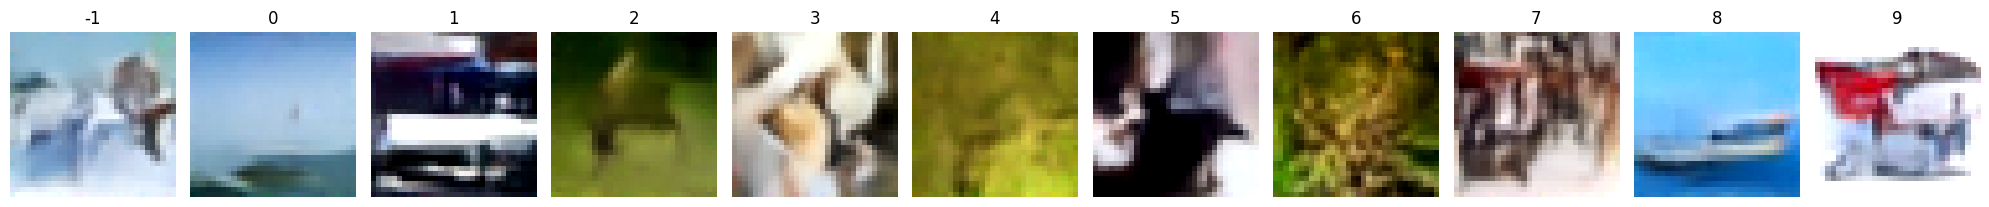

Epoch 46/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - classifier_accuracy: 0.5014 - classifier_loss: 1.3785 - loss: 0.0417 - noise_loss: 0.0299 - learning_rate: 1.5708e-05
Epoch 47/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - classifier_accuracy: 0.5028 - classifier_loss: 1.3772 - loss: 0.0417 - noise_loss: 0.0298 - learning_rate: 8.8564e-06
Epoch 48/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 132ms/step - classifier_accuracy: 0.5158 - classifier_loss: 1.3429 - loss: 0.0415 - noise_loss: 0.0299 - learning_rate: 3.9426e-06
Epoch 49/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - classifier_accuracy: 0.5022 - classifier_loss: 1.3830 - loss: 0.0415 - noise_loss: 0.0296 - learning_rate: 9.8664e-07
Epoch 50/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - classifier_accuracy: 0.5016 - classifier_loss: 1.3803 - loss: 0.0415 - noise_loss: 0.0297 - val_classifier_accuracy: 0.6621 - val_classifier_loss: 0.9381 - val_image_loss: 0.0884 - val_loss: 0.0384 - val_noise_loss: 0.0303 - learning_rate

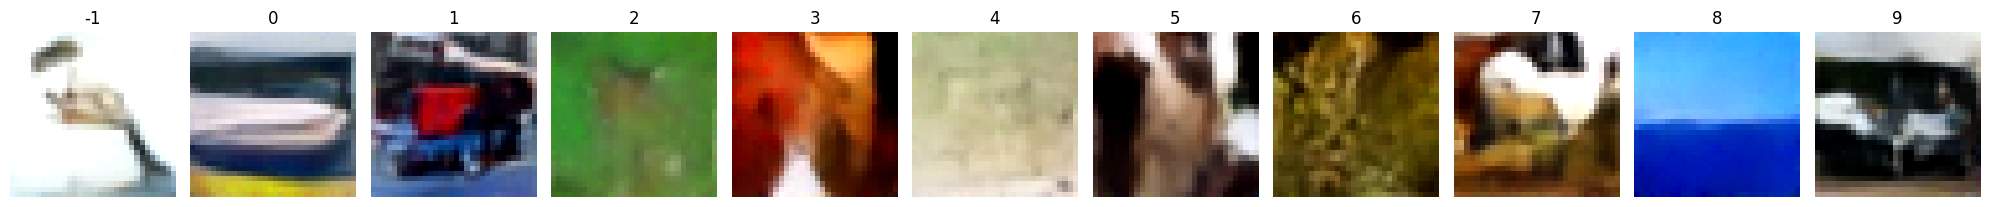

In [8]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list, 
    validation_freq=val_freq
).history

## Save weights

Save raw and EMA weights under a UNet Diffusion CLF-specific path. Rerunning this cell replaces this notebook's checkpoint.


In [9]:
model.save_weights("./files/models/CIFAR10 UNet Diffusion CLF/model.weights.h5")

## Evaluate EMA and raw networks

Report diffusion losses and classifier metrics for both networks on the same monitoring split.


In [10]:
model.evaluate(valset, network_name="ema")

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - classifier_accuracy: 0.6621 - classifier_loss: 0.9381 - image_loss: 0.0882 - loss: 0.0390 - noise_loss: 0.0309


[<tf.Tensor: shape=(), dtype=float32, numpy=0.039014045149087906>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.030946791172027588>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.08817467093467712>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.9380532503128052>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.6621000170707703>]

In [11]:
model.evaluate(valset, network_name="raw")

79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 170ms/step - classifier_accuracy: 0.6632 - classifier_loss: 0.9378 - image_loss: 0.0898 - loss: 0.0386 - noise_loss: 0.0305


[<tf.Tensor: shape=(), dtype=float32, numpy=0.03860466182231903>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.030539149418473244>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.08976399898529053>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.9378496408462524>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.6632000207901001>]

## Ensemble evaluation

Evaluate timestep ensembles with the EMA network at the same maximum timesteps used in the DiT CLF notebook.


In [21]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=256, 
    t_range_drop_rate=0.75
)

Step (79/79) --- Ensemble Accuracy: 0.6941


2026-10-08 15:25:18.118613: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


0.694100022315979

In [15]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=128, 
    t_range_drop_rate=0.75
)

Step (79/79) --- Ensemble Accuracy: 0.6962


2026-10-08 15:00:07.305821: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


0.6962000131607056

In [16]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=64, 
    t_range_drop_rate=0.75
)

Step (79/79) --- Ensemble Accuracy: 0.6957


0.6956999897956848

In [17]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=32, 
    t_range_drop_rate=0.75
)

Step (79/79) --- Ensemble Accuracy: 0.6925


2026-10-08 15:07:00.705768: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


0.6924999952316284

In [18]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=16, 
    t_range_drop_rate=0.75
)

Step (79/79) --- Ensemble Accuracy: 0.6918


0.6917999982833862

In [19]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=8, 
    t_range_drop_rate=0.75
)

Step (79/79) --- Ensemble Accuracy: 0.6889


0.6888999938964844

In [20]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=4
)

Step (79/79) --- Ensemble Accuracy: 0.6975


0.6974999904632568

## Class-conditional samples

Compare 1,000 stochastic steps, 1,000 deterministic steps, and 50 deterministic steps at guidance scales 3 and 4 using the EMA network. The first image is the null condition, followed by the ten classes. Explicit sampling condition IDs are 1–10; 0 is null. The wrapper already maps images to external pixel values. Sampling stream counters advance between calls even with a fixed seed; these grids are illustrative comparisons, not paired-noise measurements.


Steps: 1000/1000


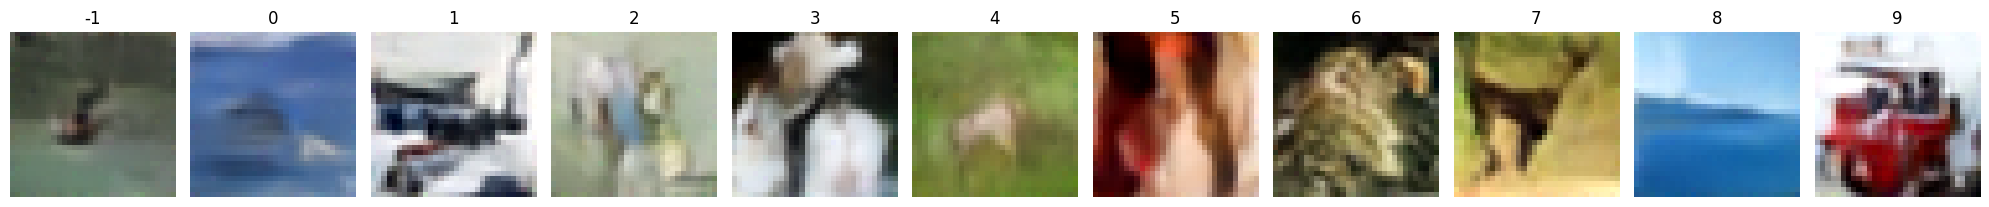

In [22]:
from common.utils import plot_images


imgs = model.sample(
    add_null_label=True, 
    scale=3., 
    eta=1., 
    steps=1000, 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


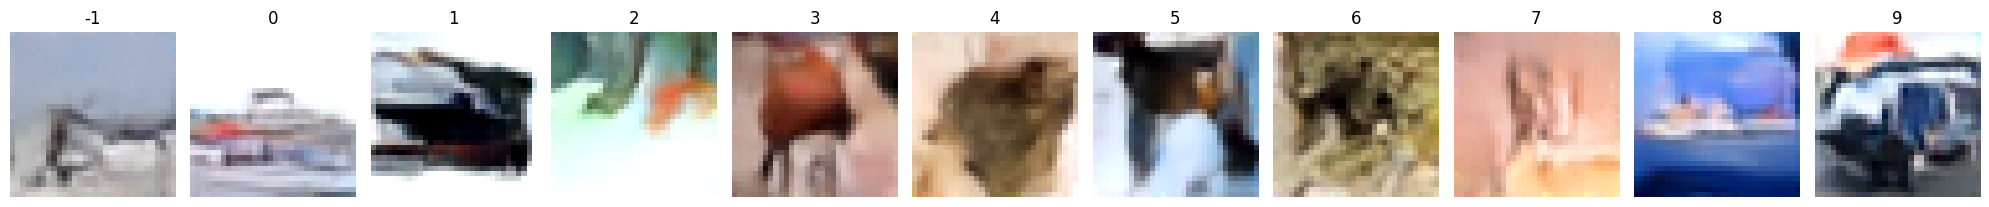

In [23]:
imgs = model.sample(
    add_null_label=True, 
    scale=3., 
    eta=0., 
    steps=1000, 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 50/50


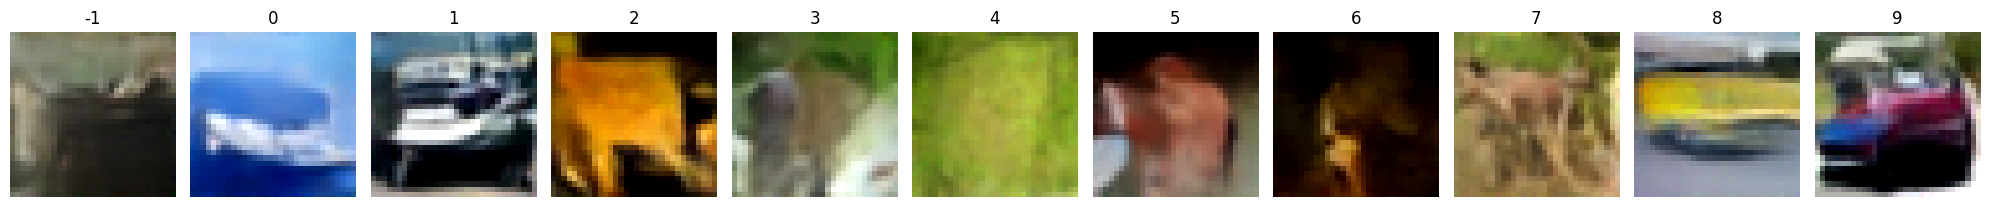

In [24]:
imgs = model.sample(
    add_null_label=True, 
    scale=3., 
    eta=0., 
    steps=50, 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 50/50


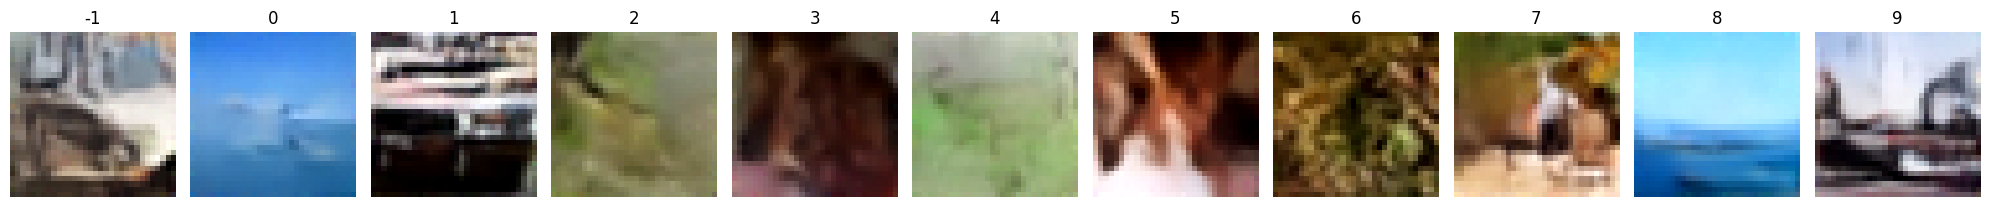

In [25]:
imgs = model.sample(
    add_null_label=True, 
    scale=4., 
    eta=0., 
    steps=50, 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

## Training history

Plot all recorded metrics, including validation-only diagnostics such as val_image_loss. The first plot infers validation spacing automatically. The second uses the known validation frequency and starts at zero-based epoch index 9 (epoch 10 onward), retaining every validation observation in that epoch range.


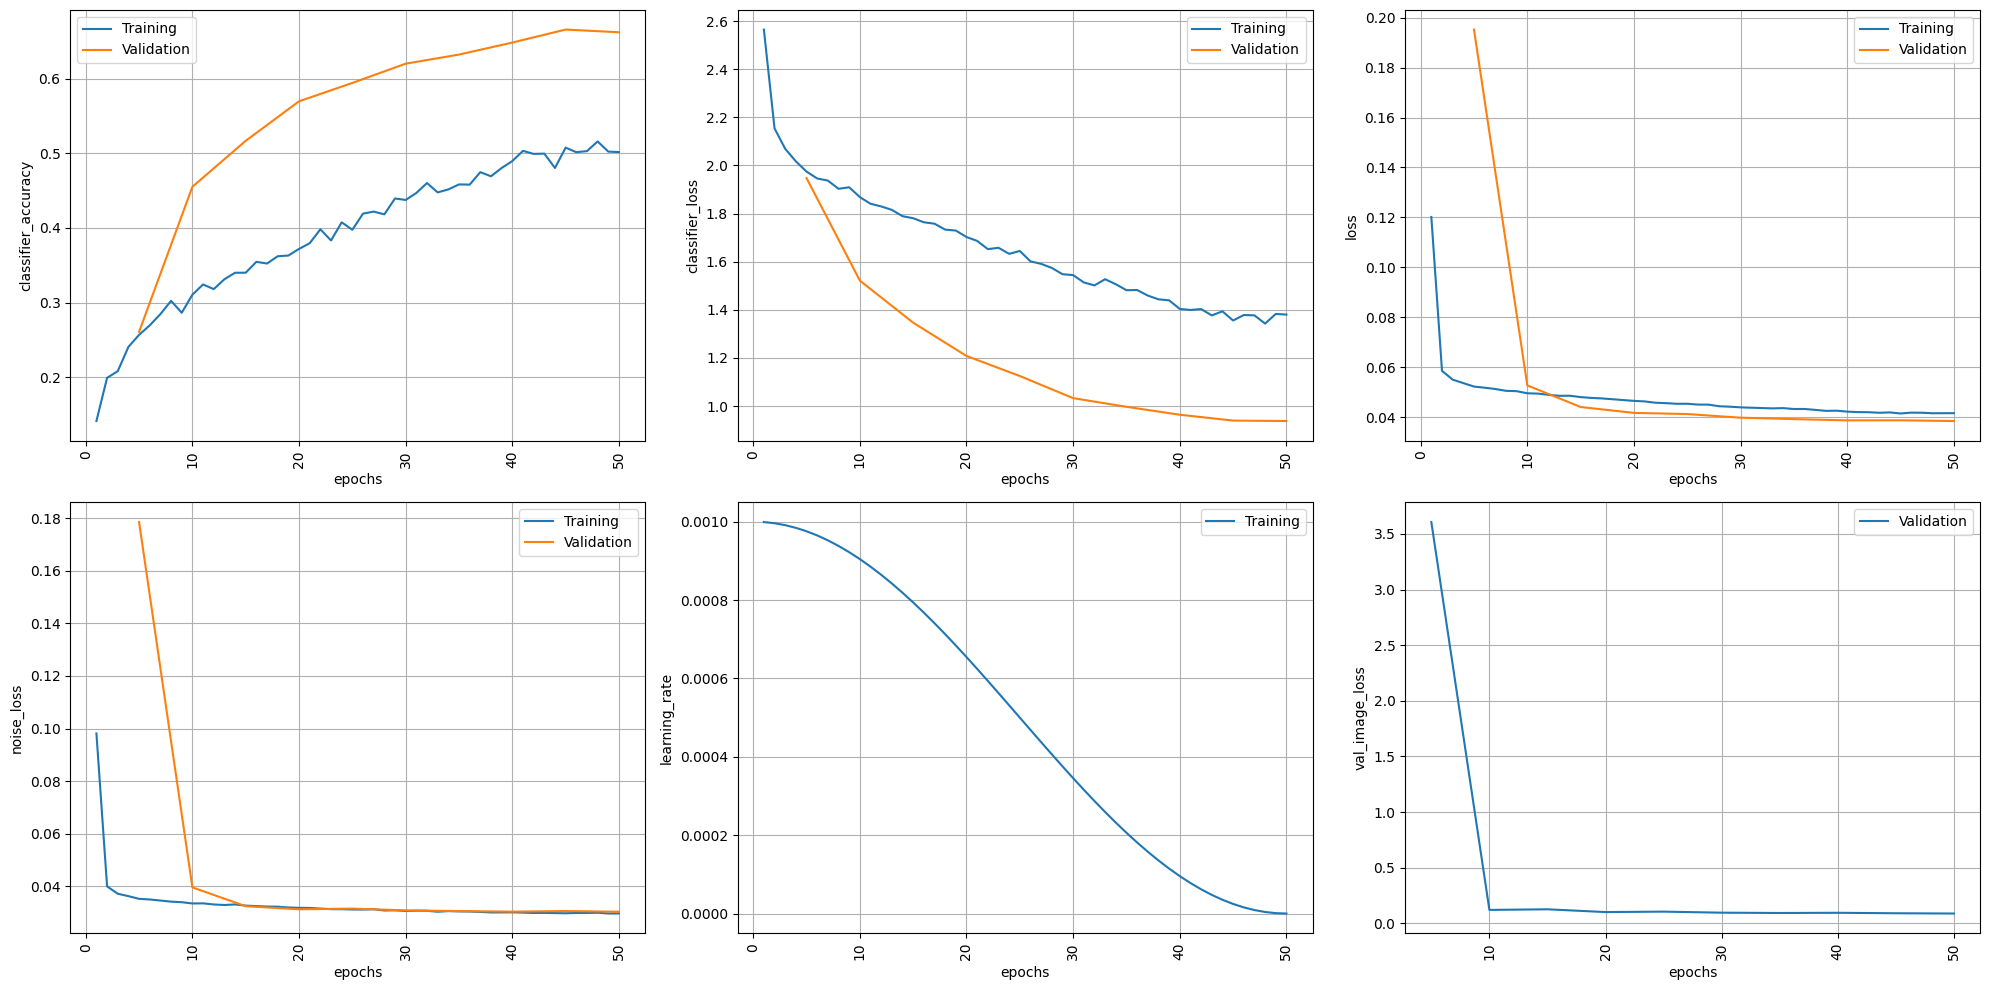

In [26]:
from common.utils import plot_history


plot_history(history, show_all_x_ticks=False)

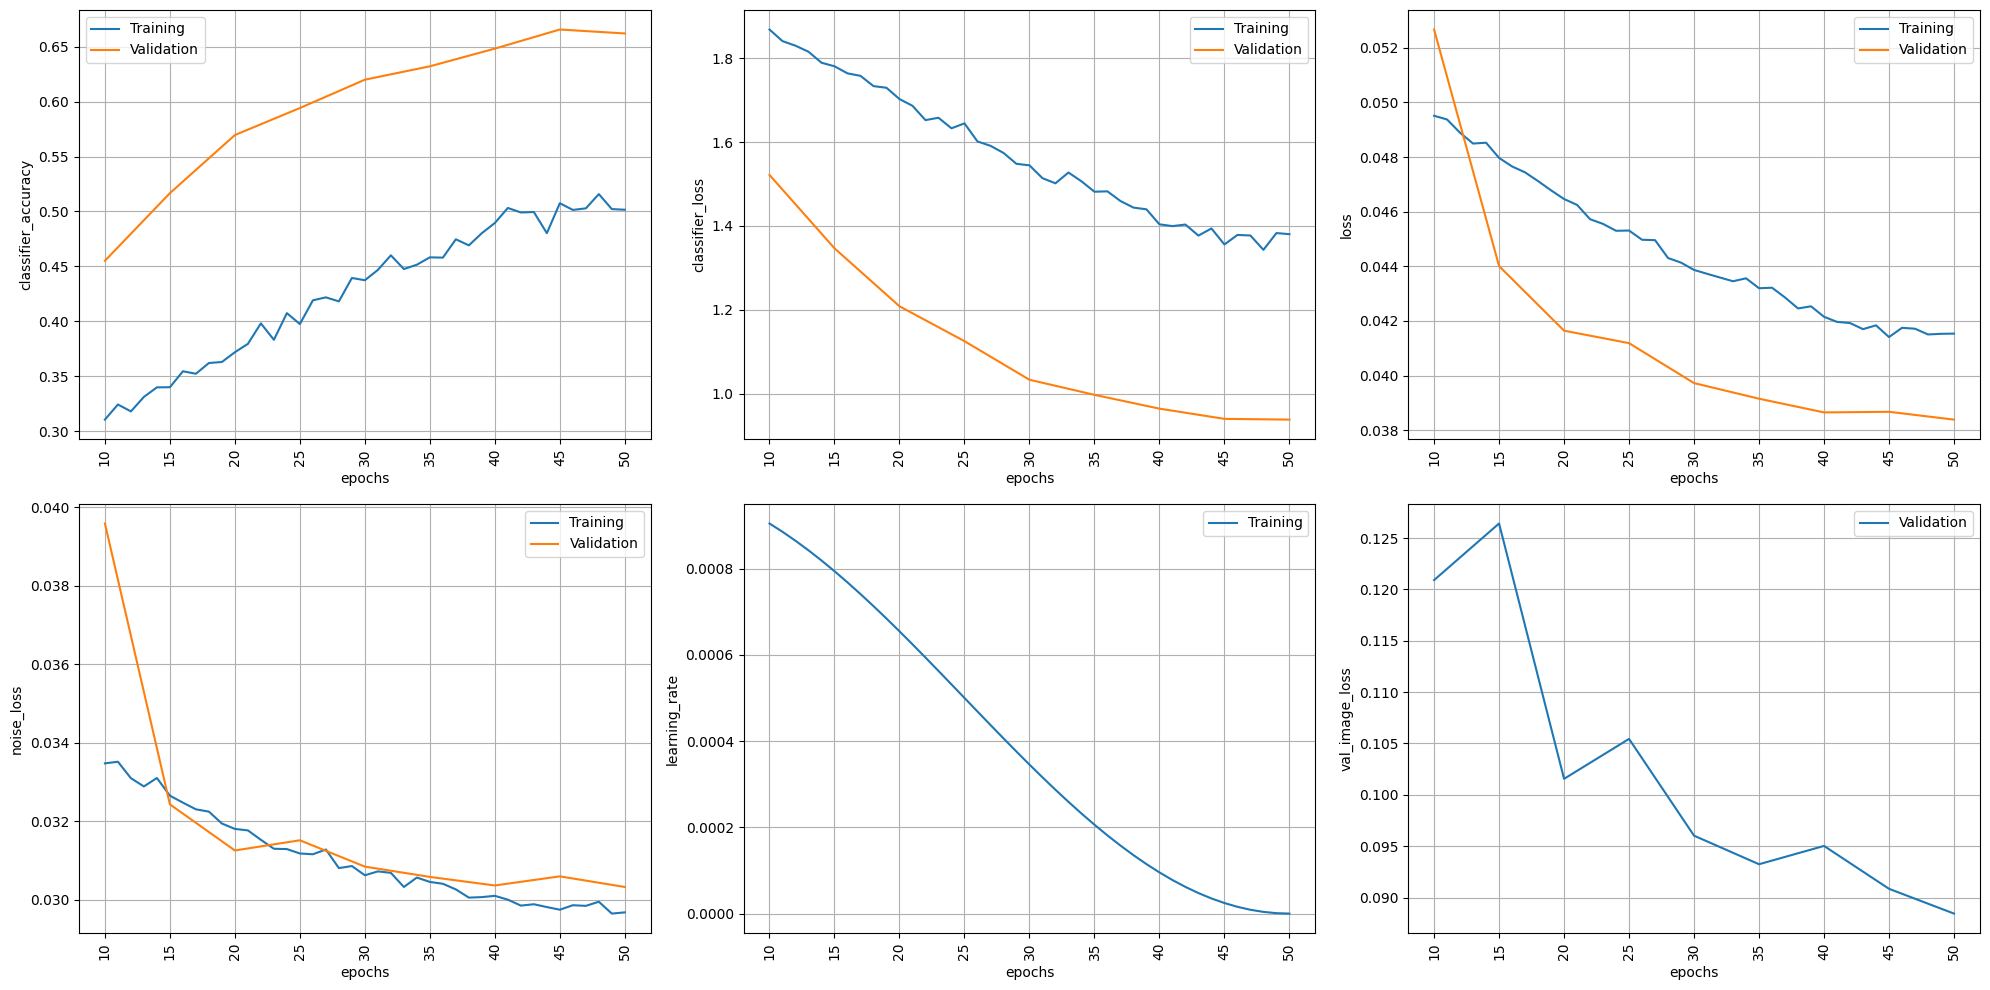

In [27]:
plot_history(history, show_all_x_ticks=False, range_=(9, None), validation_freq=val_freq)